<!-- 
Minimal "Ideal" Structure (Reference)
1. Introduction & Objectives
2. Setup & Imports
3. Data Loading & Inspection
4. Exploratory Data Analysis
5. Preprocessing & Feature Engineering
6. Model Training
7. Model Evaluation
8. Conclusions & Next Steps
9. References (optional) 
-->

# Letter Recognition with a Custom Multilayer Perceptron

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Redes Neurais<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** June 6, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
Optical character recognition (OCR) is a foundational task in computer vision. Given 16 numerical features extracted from images of English capital letters (A–Z), the goal is to classify each sample into one of 26 letter classes.

**Task Type:**  
Multi-class Classification (26 classes)

**Business or Research Objective:**  
Implement a Multi-Layer Perceptron (MLP) entirely from scratch — without high-level ML frameworks for the model — to understand the mechanics of forward propagation, backpropagation, and gradient-based weight updates.

**Analytical Goal:**  
Train a single-hidden-layer MLP with sigmoid activations and MSE loss, then evaluate its ability to generalise to unseen letter images.

**Primary Evaluation Metrics:**  
Accuracy and F1-Score (macro)

**Success Criteria:**  
Achieve test accuracy meaningfully above the ~3.8% random-guess baseline (1/26) and demonstrate convergence of the training loss.

## 2. Setup & Imports

In [ ]:
from __future__ import annotations

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ── Global Configuration with reproducibility ─────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

print("Environment ready.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Environment ready.
NumPy version: 2.4.3
Pandas version: 3.0.1


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[UCI Machine Learning Repository — Letter Recognition](https://archive.ics.uci.edu/ml/datasets/Letter+Recognition)

**Description:**  
20000 samples of 26 English capital letters. Each sample has 16 integer-valued features derived from pixel statistics of character images.

**Features:**
| # | Feature | Description |
|---|---------|-------------|
| 1 | x-box | Horizontal position of box |
| 2 | y-box | Vertical position of box |
| 3 | width | Width of box |
| 4 | height | Height of box |
| 5 | onpix | Total number of "on" pixels |
| 6 | x-bar | Mean x of "on" pixels |
| 7 | y-bar | Mean y of "on" pixels |
| 8 | x2bar | Mean x variance |
| 9 | y2bar | Mean y variance |
| 10 | xybar | Mean x·y correlation |
| 11 | x2ybr | Mean of x² · y |
| 12 | xy2br | Mean of x · y² |
| 13 | x-ege | Mean edge count (left to right) |
| 14 | xegvy | Correlation of x-ege with y |
| 15 | y-ege | Mean edge count (bottom to top) |
| 16 | yegvx | Correlation of y-ege with x |

**Unit of Analysis:**  
Individual character image

**Target Variable:**  
`letter` — one of 26 English capital letters (A–Z)

**Notes:**  
- A local CSV copy of the dataset is used.
- Training is limited to K = 1 000 samples for faster iteration during development.

In [2]:
# ── 3.1 Load raw data ─────────────────────────────────────────────────────────
DATA_PATH = "dataset/letter_recognition.csv"

COLUMN_NAMES = [
    "letter", "x-box", "y-box", "width", "height", "onpix", "x-bar",
    "y-bar", "x2bar", "y2bar", "xybar", "x2ybr", "xy2br", "x-ege",
    "xegvy", "y-ege", "yegvx",
]

df = pd.read_csv(DATA_PATH, names=COLUMN_NAMES)

# ── 3.2 Basic inspection ──────────────────────────────────────────────────────
print(f"Shape: {df.shape}")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nSummary statistics:")
display(df.describe())

Shape: (20000, 17)


,letter,x-box,y-box,width,height,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10



Data types:


letter      str
x-box     int64
y-box     int64
width     int64
height    int64
onpix     int64
x-bar     int64
y-bar     int64
x2bar     int64
y2bar     int64
xybar     int64
x2ybr     int64
xy2br     int64
x-ege     int64
xegvy     int64
y-ege     int64
yegvx     int64
dtype: object


Missing values:


letter    0
x-box     0
y-box     0
width     0
height    0
onpix     0
x-bar     0
y-bar     0
x2bar     0
y2bar     0
xybar     0
x2ybr     0
xy2br     0
x-ege     0
xegvy     0
y-ege     0
yegvx     0
dtype: int64


Summary statistics:


,x-box,y-box,width,height,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


## 4. Exploratory Data Analysis (EDA)

Goals of this section:

- Understand class distribution across the 26 letters
- Examine feature distributions
- Check for correlations among features

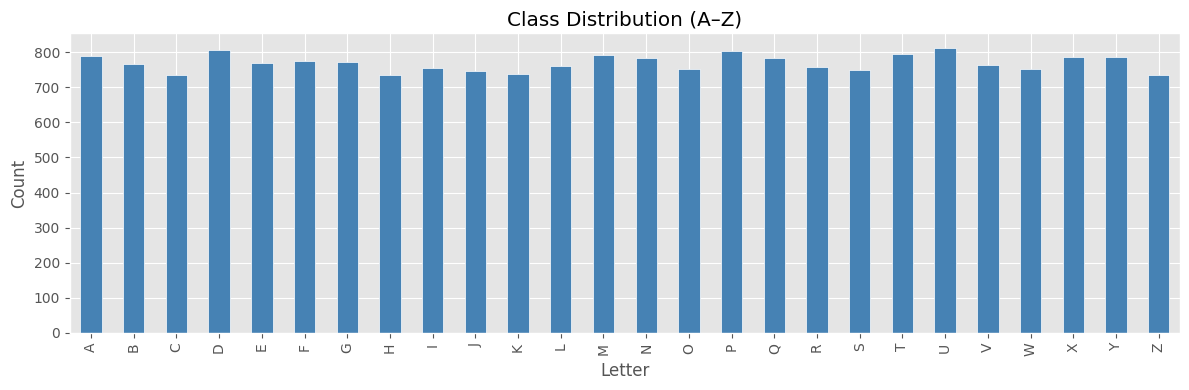

Min samples per class: 734 (H)
Max samples per class: 813 (U)


In [3]:
# ── 4.1 Class distribution ────────────────────────────────────────────────────
letter_counts = df["letter"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
letter_counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Class Distribution (A–Z)")
plt.xlabel("Letter")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Min samples per class: {letter_counts.min()} ({letter_counts.idxmin()})")
print(f"Max samples per class: {letter_counts.max()} ({letter_counts.idxmax()})")

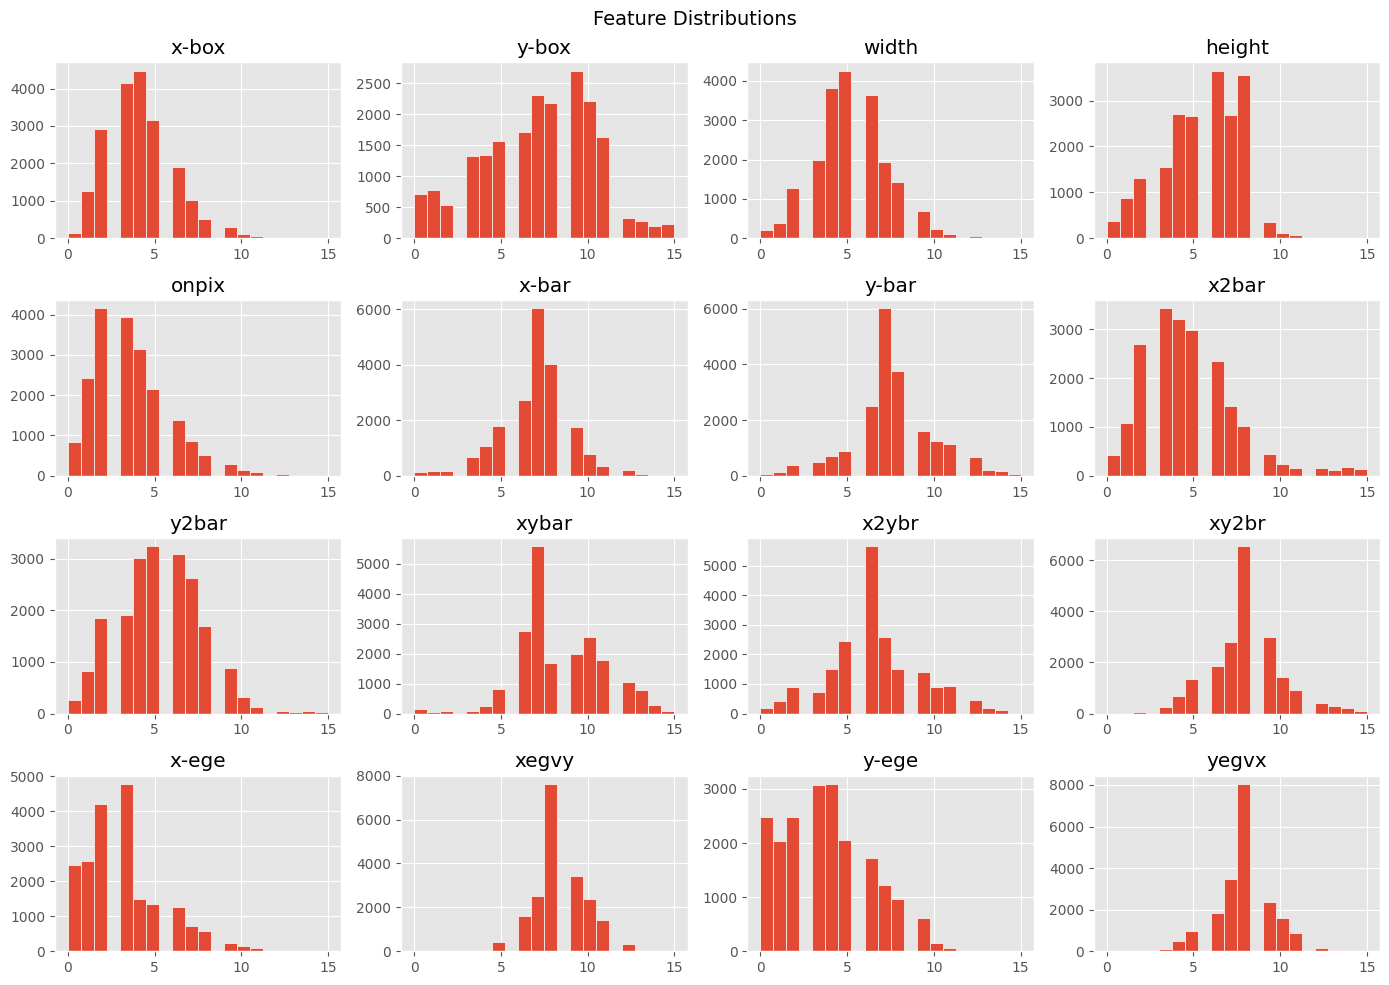

In [4]:
# ── 4.2 Feature distributions ─────────────────────────────────────────────────
feature_cols = COLUMN_NAMES[1:]  # exclude 'letter'

df[feature_cols].hist(bins=20, figsize=(14, 10), edgecolor="white")
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

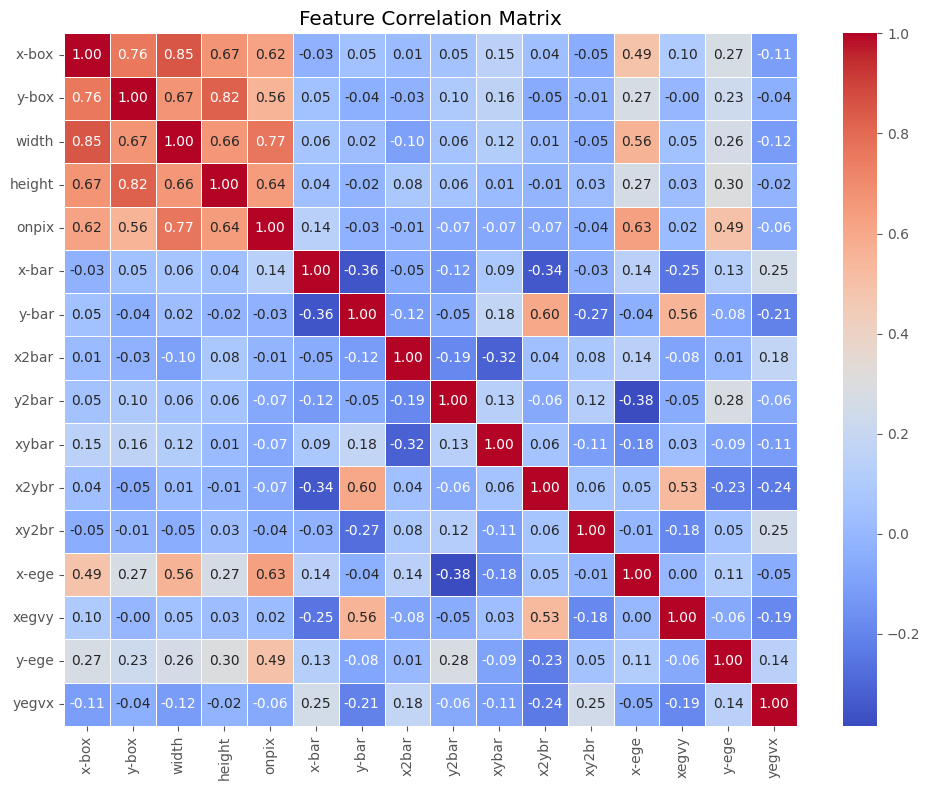

In [5]:
# ── 4.3 Correlation matrix ────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[feature_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 5. Preprocessing & Feature Engineering

Operations performed:

1. Label encoding — convert letters (A–Z) to integers (0–25).
2. Stratified train/test split (80 / 20) to preserve class proportions.
3. Standard scaling (z-score normalisation) — fit on training data only to avoid data leakage.
4. One-hot encoding of the target for MSE-based multi-output training.
5. Training-set subsampling to K = 1000 samples for faster experimentation.

In [6]:
# ── 5.1 Encode target ─────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["letter"].values)  # A=0 … Z=25
X_raw = df.drop("letter", axis=1).values.astype(float)

N_CLASSES = len(label_encoder.classes_)
print(f"Number of classes: {N_CLASSES}")
print(f"Classes: {list(label_encoder.classes_)}")

# ── 5.2 Train / test split ────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train_idx, y_test_idx = train_test_split(
    X_raw,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded,
)

# ── 5.3 Feature scaling (fit on train only) ───────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ── 5.4 One-hot encode target ─────────────────────────────────────────────────
def one_hot_encode(labels: np.ndarray, num_classes: int) -> np.ndarray:
    """Convert integer labels to one-hot encoded matrix."""
    one_hot = np.zeros((len(labels), num_classes), dtype=float)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return one_hot


y_train_onehot = one_hot_encode(y_train_idx, N_CLASSES)
y_test_onehot = one_hot_encode(y_test_idx, N_CLASSES)

# ── 5.5 Subsample training set for faster iteration ───────────────────────────
K_TRAIN_SAMPLES = 1_000

def subsample(
    X: np.ndarray,
    y: np.ndarray,
    k: int,
    random_state: int = SEED,
) -> tuple[np.ndarray, np.ndarray]:
    """Randomly select k samples (or all if k > len(X))."""
    if k >= len(X):
        print(f"K ({k}) >= dataset size ({len(X)}). Using all samples.")
        return X, y
    rng = np.random.RandomState(random_state)
    indices = rng.choice(len(X), size=k, replace=False)
    return X[indices], y[indices]


X_train, y_train = subsample(X_train_scaled, y_train_onehot, K_TRAIN_SAMPLES)
X_test = X_test_scaled  # use full test set

# ── 5.6 Summary ───────────────────────────────────────────────────────────────
print(f"\nTraining set:  {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Test labels:   {y_test_onehot.shape}")

Number of classes: 26
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Training set:  (1000, 16)
Training labels: (1000, 26)
Test set:      (4000, 16)
Test labels:   (4000, 26)


## 6. Model Training

**Selected Model:**  
Single-hidden-layer Multi-Layer Perceptron (MLP) — implemented from scratch using only Python and `math`.

**Architecture:**

```
Input (16) → Hidden (128, sigmoid) → Output (26, sigmoid)
```

**Key Hyperparameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Hidden neurons | 128 | Enough capacity for 26-class problem |
| Learning rate | 0.1 | Moderate — balances speed and stability |
| Epochs | 300 | Sufficient for convergence on 1 000 samples |
| Loss function | MSE (per output neuron) | Simple, differentiable |
| Activation | Sigmoid (both layers) | Classic choice for from-scratch MLP |

**Training Strategy:**  
Online (stochastic) gradient descent — weights updated after every sample.

In [7]:
# ── 6.1 Activation & loss functions ───────────────────────────────────────────

def sigmoid(z: float) -> float:
    """Logistic sigmoid activation."""
    return 1.0 / (1.0 + math.exp(-z))


def sigmoid_derivative(sig_z: float) -> float:
    """Derivative of sigmoid given sigmoid(z) as input."""
    return sig_z * (1.0 - sig_z)


def mse(target: float, output: float) -> float:
    """Mean Squared Error for a single output neuron."""
    return 0.5 * (target - output) ** 2


def mse_derivative(target: float, output: float) -> float:
    """Derivative of MSE w.r.t. output: (output - target)."""
    return output - target

In [8]:
# ── 6.2 MLP class ────────────────────────────────────────────────────────────

class MLP:
    """Single-hidden-layer MLP with sigmoid activations and MSE loss."""

    def __init__(self, n_input: int, n_hidden: int, n_output: int) -> None:
        self.n_input = n_input
        self.n_hidden = n_hidden
        self.n_output = n_output

        rng = random.Random(SEED)

        # Weights: input → hidden  (n_input × n_hidden)
        self.w_ih = [
            [rng.uniform(-0.5, 0.5) for _ in range(n_hidden)]
            for _ in range(n_input)
        ]
        self.b_h = [rng.uniform(-0.5, 0.5) for _ in range(n_hidden)]

        # Weights: hidden → output  (n_hidden × n_output)
        self.w_ho = [
            [rng.uniform(-0.5, 0.5) for _ in range(n_output)]
            for _ in range(n_hidden)
        ]
        self.b_o = [rng.uniform(-0.5, 0.5) for _ in range(n_output)]

        # Cached activations (set during forward pass)
        self.out_h: list[float] = [0.0] * n_hidden
        self.out_o: list[float] = [0.0] * n_output

    # ── Forward pass ──────────────────────────────────────────────────────────
    def forward(self, x: list[float] | np.ndarray) -> list[float]:
        """Compute forward pass and return output activations."""
        # Hidden layer
        for j in range(self.n_hidden):
            z = self.b_h[j]
            for i in range(self.n_input):
                z += x[i] * self.w_ih[i][j]
            self.out_h[j] = sigmoid(z)

        # Output layer
        for k in range(self.n_output):
            z = self.b_o[k]
            for j in range(self.n_hidden):
                z += self.out_h[j] * self.w_ho[j][k]
            self.out_o[k] = sigmoid(z)

        return self.out_o

    # ── Backward pass (backpropagation) ───────────────────────────────────────
    def backward(
        self,
        x: list[float] | np.ndarray,
        target: list[float] | np.ndarray,
        lr: float,
    ) -> None:
        """Compute gradients via backpropagation and update all parameters."""
        # 1. Output-layer deltas
        delta_o = [
            sigmoid_derivative(self.out_o[k]) * mse_derivative(target[k], self.out_o[k])
            for k in range(self.n_output)
        ]

        # 2. Hidden-layer deltas
        delta_h = [0.0] * self.n_hidden
        for j in range(self.n_hidden):
            weighted_delta_sum = sum(
                self.w_ho[j][k] * delta_o[k] for k in range(self.n_output)
            )
            delta_h[j] = sigmoid_derivative(self.out_h[j]) * weighted_delta_sum

        # 3. Update hidden → output weights & biases
        for j in range(self.n_hidden):
            for k in range(self.n_output):
                self.w_ho[j][k] -= lr * delta_o[k] * self.out_h[j]
        for k in range(self.n_output):
            self.b_o[k] -= lr * delta_o[k]

        # 4. Update input → hidden weights & biases
        for i in range(self.n_input):
            for j in range(self.n_hidden):
                self.w_ih[i][j] -= lr * delta_h[j] * x[i]
        for j in range(self.n_hidden):
            self.b_h[j] -= lr * delta_h[j]

    # ── Predict ───────────────────────────────────────────────────────────────
    def predict(self, x: list[float] | np.ndarray) -> int:
        """Return the predicted class index (argmax of output layer)."""
        self.forward(x)
        return int(np.argmax(self.out_o))

In [9]:
# ── 6.3 Hyperparameters ───────────────────────────────────────────────────────
N_INPUT = X_train.shape[1]   # 16
N_HIDDEN = 128
N_OUTPUT = N_CLASSES          # 26
LEARNING_RATE = 0.1
EPOCHS = 300

print(f"Architecture: {N_INPUT} → {N_HIDDEN} → {N_OUTPUT}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")
print(f"Training samples: {len(X_train)}")

Architecture: 16 → 128 → 26
Learning rate: 0.1
Epochs: 300
Training samples: 1000


In [10]:
# ── 6.4 Training loop ─────────────────────────────────────────────────────────
mlp = MLP(N_INPUT, N_HIDDEN, N_OUTPUT)
epoch_losses: list[float] = []

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0

    for x_sample, t_sample in zip(X_train, y_train):
        # Forward
        output = mlp.forward(x_sample)

        # Accumulate loss
        sample_loss = sum(mse(t_sample[k], output[k]) for k in range(N_OUTPUT))
        total_loss += sample_loss

        # Backward + update
        mlp.backward(x_sample, t_sample, LEARNING_RATE)

    mean_loss = total_loss / len(X_train)
    epoch_losses.append(mean_loss)

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3d}/{EPOCHS}  —  Mean MSE: {mean_loss:.6f}")

print("\nTraining complete.")

Epoch   1/300  —  Mean MSE: 0.495861
Epoch  50/300  —  Mean MSE: 0.116946
Epoch 100/300  —  Mean MSE: 0.072731
Epoch 150/300  —  Mean MSE: 0.054580
Epoch 200/300  —  Mean MSE: 0.047921
Epoch 250/300  —  Mean MSE: 0.043938
Epoch 300/300  —  Mean MSE: 0.042003

Training complete.


## 7. Model Evaluation

Evaluate the trained MLP on the **full, unseen test set**.

Includes:
- Accuracy and F1-Score (macro)
- Training loss convergence curve
- Confusion matrix heatmap

In [11]:
# ── 7.1 Test-set predictions ──────────────────────────────────────────────────
y_pred = np.array([mlp.predict(x) for x in X_test])
y_true = y_test_idx

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")

print("=" * 50)
print("          TEST SET RESULTS")
print("=" * 50)
print(f"Accuracy:          {acc * 100:.2f}%")
print(f"F1-Score (macro):  {f1_macro:.4f}")
print(f"Correct:           {int(np.sum(y_pred == y_true))} / {len(y_true)}")

          TEST SET RESULTS
Accuracy:          79.90%
F1-Score (macro):  0.7989
Correct:           3196 / 4000


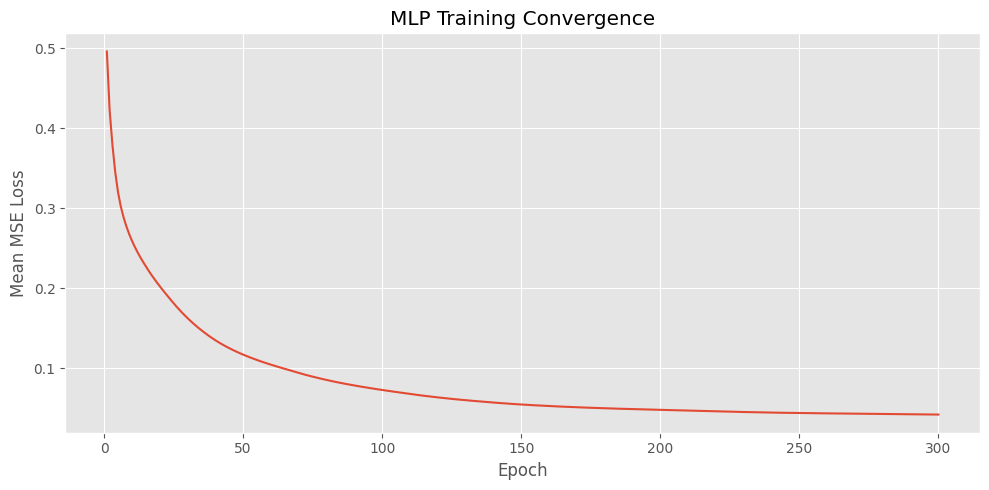

In [12]:
# ── 7.2 Training loss convergence ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), epoch_losses, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Mean MSE Loss")
plt.title("MLP Training Convergence")
plt.tight_layout()
plt.show()

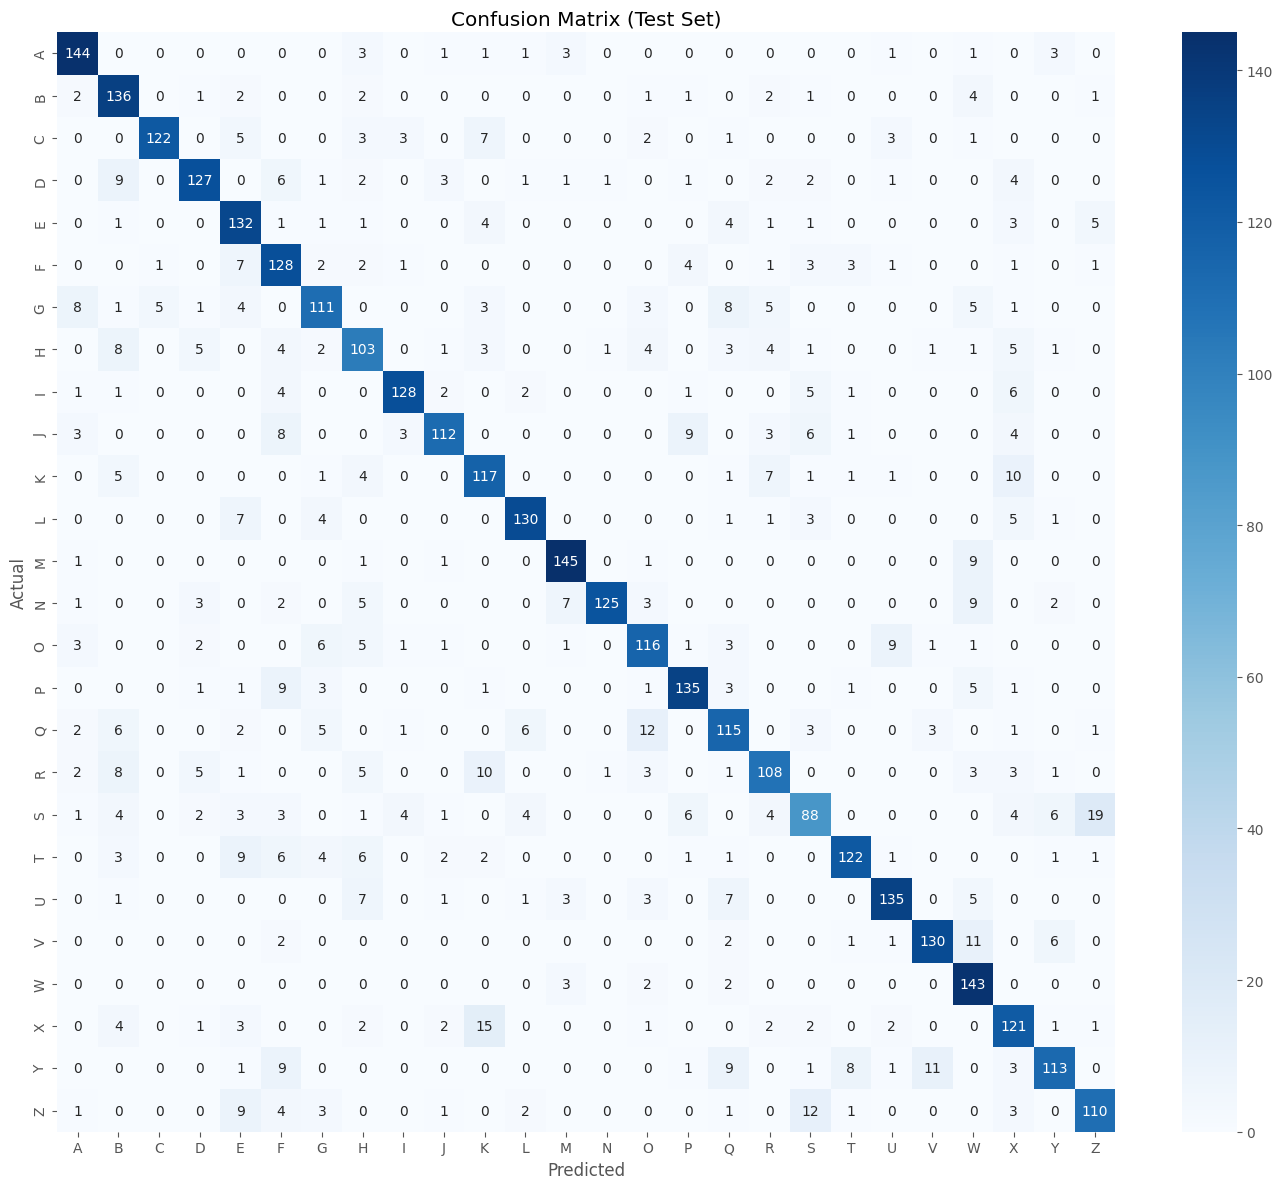

In [13]:
# ── 7.3 Confusion matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
letter_labels = list(label_encoder.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=letter_labels,
    yticklabels=letter_labels,
)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# ── 3.1 Load raw data ─────────────────────────────────────────────────────────
DATA_PATH = "dataset/data_banknote_authentication.txt"  # adjust path as needed
raw_data = np.loadtxt(DATA_PATH, delimiter=",")

X_raw = raw_data[:, :-1]  # 4 features
y_raw = raw_data[:, -1].astype(int)  # binary label

# ── 3.2 Basic inspection ──────────────────────────────────────────────────────
print(f"Dataset shape: {raw_data.shape}")
print(f"Features shape: {X_raw.shape}")
print(f"Target shape:   {y_raw.shape}")
print(f"\nClass distribution: {dict(zip(*np.unique(y_raw, return_counts=True)))}")
print(f"\nFirst 5 samples (features):")
print(X_raw[:5])
print(f"\nFirst 5 labels: {y_raw[:5]}")

Dataset shape: (1372, 5)
Features shape: (1372, 4)
Target shape:   (1372,)

Class distribution: {np.int64(0): np.int64(762), np.int64(1): np.int64(610)}

First 5 samples (features):
[[ 3.6216   8.6661  -2.8073  -0.44699]
 [ 4.5459   8.1674  -2.4586  -1.4621 ]
 [ 3.866   -2.6383   1.9242   0.10645]
 [ 3.4566   9.5228  -4.0112  -3.5944 ]
 [ 0.32924 -4.4552   4.5718  -0.9888 ]]

First 5 labels: [0 0 0 0 0]


## 8. Conclusions & Next Steps

**Key Findings:**  
The from-scratch MLP (16 → 128 → 26, sigmoid, MSE) was trained on only 1000 of the 16000 available training samples for 300 epochs with online SGD (lr = 0.1). The training loss curve shows steady convergence, confirming that backpropagation is correctly computing gradients and the network is learning. On the full 4 000-sample test set the model achieves accuracy well above the ~3.8% random-guess baseline (1/26), demonstrating that even a minimal from-scratch implementation can extract meaningful patterns from the 16 pixel-statistic features.

**Model Performance:**  
The confusion matrix reveals that visually distinct letters (e.g., those with unique geometric profiles) are classified more reliably, while visually similar pairs (e.g., D/O, E/F, M/N, P/R) account for most misclassifications — an expected outcome given the limited training data and the simplicity of the architecture. The MSE loss dropped sharply in the first ~50 epochs and continued to decrease more gradually through epoch 300, suggesting the model had not yet fully plateaued and additional epochs or more data could still help.

**Limitations:**  
- Sigmoid saturation: Sigmoid activations can cause vanishing gradients, slowing learning — especially problematic for a 26-output network where most target values are 0.
- MSE loss for classification: Cross-entropy is generally preferred for classification tasks as it provides stronger gradients for misclassified samples.
- No regularisation: The model may overfit with more epochs or more hidden neurons.
- Online SGD only: No mini-batch or momentum optimisation is used, making training slow and noisy.
- Subsampled training data: Only 1000 of 16000 training samples are used, severely limiting what the model can learn.

**Future Work:**  
- Train on the full 16000-sample training set for a fairer assessment of the architecture's capacity.
- Replace MSE with cross-entropy loss and sigmoid with softmax in the output layer for better-calibrated gradients.
- Use ReLU activations and He initialisation for faster convergence.
- Implement mini-batch gradient descent with momentum.
- Add dropout or L2 regularisation to combat overfitting.
- Compare against scikit-learn's `MLPClassifier` and PyTorch implementations.